In [12]:
import torch # for tensor operations 
import torch.nn as nn # for neural network modules
from sklearn.datasets import make_moons # for generating the two moon dataset
import math # for mathematical functions
from scipy.stats import special_ortho_group # for generating random orthogonal matrices
import random # for random number generation
import matplotlib.pyplot as plt # for plotting the results


Text(0.5, 1.0, 'Two moon dataset')

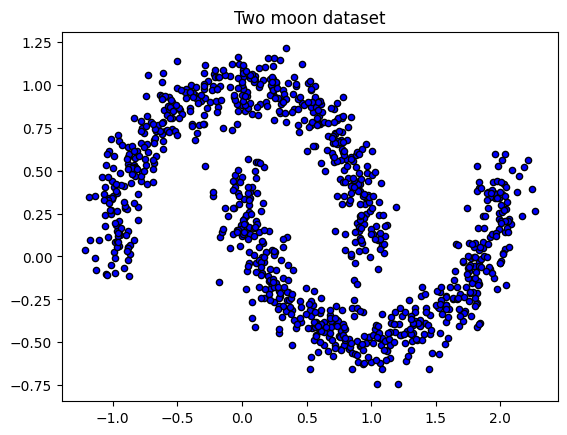

In [13]:
test_x_, _ = make_moons(n_samples=1000, shuffle=True, noise=0.1, random_state=42) # here the two moon dataset is generated with 1000 samples in a 2d array all under test_x_ and the labels are ignored with _. So, both the x and y coordinates of the two moon dataset are stored in test_x_.  
plt.scatter(test_x_[:, 0], test_x_[:, 1], c="blue", s=20, edgecolor="k") # here the two moon dataset is plotted with blue color and size 20 for the points and black edge color. The x coordinates are taken from the first column of test_x_ and the y coordinates are taken from the second column of test_x_.
plt.title("Two moon dataset")

In [14]:

def subnet_constructor(input_size, hidden_size, output_size):
    model = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, output_size)
    )
    return model        

In [15]:
# why do we need an orthogonal matrix? We need an orthogonal matrix to ensure that the transformation is invertible and to maintain the volume of the transformed space. An orthogonal matrix has the property that its inverse is equal to its transpose, which makes it easier to compute the inverse transformation. Additionally, using an orthogonal matrix helps to preserve the structure of the data and prevents distortion during the transformation process.  
def orthogoanl_matrix(dim):
    """ A = torch.normal (mean = torch.zeros (dim, dim), std = torch.ones (dim, dim))
    Q, _ = torch.qr (A)
    if dim == 2:
        Q[1,1] = -Q[0,0]
        Q[1,0] = -Q[0,1]
    print (torch.linalg.det(Q))
    return Q
    """
    Q = special_ortho_group.rvs(dim)
    return torch.Tensor (Q)

In [16]:
class coupling_block(nn.Module):
 def __init__(self, input_size, hidden_size):
    super().__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.split1 = math.floor(self.input_size/2)
    self.split2 = self.input_size - self.split1
    self.subnet = subnet_constructor(self.split1, self.hidden_size, 2*self.split2)
 def forward(self, x, rev=False):
    x1, x2 = x[..., :self.split1], x[..., self.split1:]
    params = self.subnet(x1)
    s, t = params[...,:self.split2], params[...,self.split2:]
    s = torch.tanh(s)
    ljd = torch.sum(s, -1)
    if not rev:
        s = torch.exp(s)
        x2 = s*x2 + t
        return torch.cat([x1,x2], -1), ljd
    if rev:
        s = torch.exp(-s)
        x2 = s * (x2-t)
        return torch.cat([x1,x2], -1)

In [17]:
class realNVP(nn.Module): 
    def __init__(self, input_size, hidden_size, n_blocks):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.n_blocks = n_blocks

        self.coupling_blocks = nn.ModuleList([coupling_block(input_size, hidden_size) for _ in range(n_blocks)])
        self.orthogonal_matrices = [orthogoanl_matrix(input_size) for _ in range(n_blocks-1)]

    def forward(self, x, rev=False):
        if rev: return self._inverse(x)
        return self._forward(x)
    def _forward(self, x):
        ljd = torch.zeros((x.shape[0]))
        for l in range(self.n_blocks-1):
            x, partial_ljd = self.coupling_blocks[l](x)
            ljd += partial_ljd
            x = torch.matmul(x, self.orthogonal_matrices[l])
        x, partial_ljd = self.coupling_blocks[-1](x)
        ljd += partial_ljd
        return x, ljd
    def _inverse(self, x):
        for l in range (self.n_blocks-1, 0, -1):
            x = self.coupling_blocks[l](x, rev=True)
            x = torch.matmul(x, self.orthogonal_matrices[l-1].T)
        x = self.coupling_blocks[0](x, rev=True)
        return x
    def sample(self, num_samples):
        z = torch.normal(mean=torch.zeros((num_samples, self.input_size)), std=torch.ones((num_samples, self.input_size)))
        return self._inverse(z)
    
    

In [21]:
def train_inn(model, batchsize=1000, epochs=1000, lr=0.001):
    optimizer = torch.optim.Adam(params=model.parameters(), lr=lr)
    for epoch in range(epochs):
        optimizer.zero_grad()
        x_data, y_data = make_moons(n_samples=batchsize, shuffle=True, noise=0.1, random_state=42)
        x_data, y_data = torch.Tensor(x_data), torch.Tensor(y_data)
        z, ljd = model(x_data)
        loss = torch.sum(0.5*torch.sum(z**2, -1)-ljd) / batchsize
        loss.backward()
        optimizer.step()
        if (epoch+1) % (epochs//3) == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

In [22]:
def plot_samples(model, title="Generated samples from INN", axs=None):
 samples = model.sample(1000)
 samples = samples.detach().numpy()
 if axs is None:
  fig, axs = plt.subplots(1,1)
  axs.scatter(samples[:,0], samples[:,1])
  axs.set_title(title)
 else:
  axs.scatter(samples[:,0], samples[:,1])
  axs.set_title(title)

Training of INN with hidden_size 16 and 2 coupling blocks started.
Epoch [33/100], Loss: 0.3445
Epoch [66/100], Loss: 0.1658
Epoch [99/100], Loss: 0.0523
Training of INN with hidden_size 64 and 2 coupling blocks started.
Epoch [33/100], Loss: -0.0101
Epoch [66/100], Loss: -0.1475
Epoch [99/100], Loss: -0.2160
Training of INN with hidden_size 128 and 2 coupling blocks started.
Epoch [33/100], Loss: -0.1432
Epoch [66/100], Loss: -0.2036
Epoch [99/100], Loss: -0.2735
Training of INN with hidden_size 16 and 5 coupling blocks started.
Epoch [33/100], Loss: 0.0207
Epoch [66/100], Loss: -0.0623
Epoch [99/100], Loss: -0.1493
Training of INN with hidden_size 64 and 5 coupling blocks started.
Epoch [33/100], Loss: -0.1971
Epoch [66/100], Loss: -0.5054
Epoch [99/100], Loss: -0.6261
Training of INN with hidden_size 128 and 5 coupling blocks started.
Epoch [33/100], Loss: -0.3185
Epoch [66/100], Loss: -0.4751
Epoch [99/100], Loss: -0.5715
Training of INN with hidden_size 16 and 10 coupling blocks s

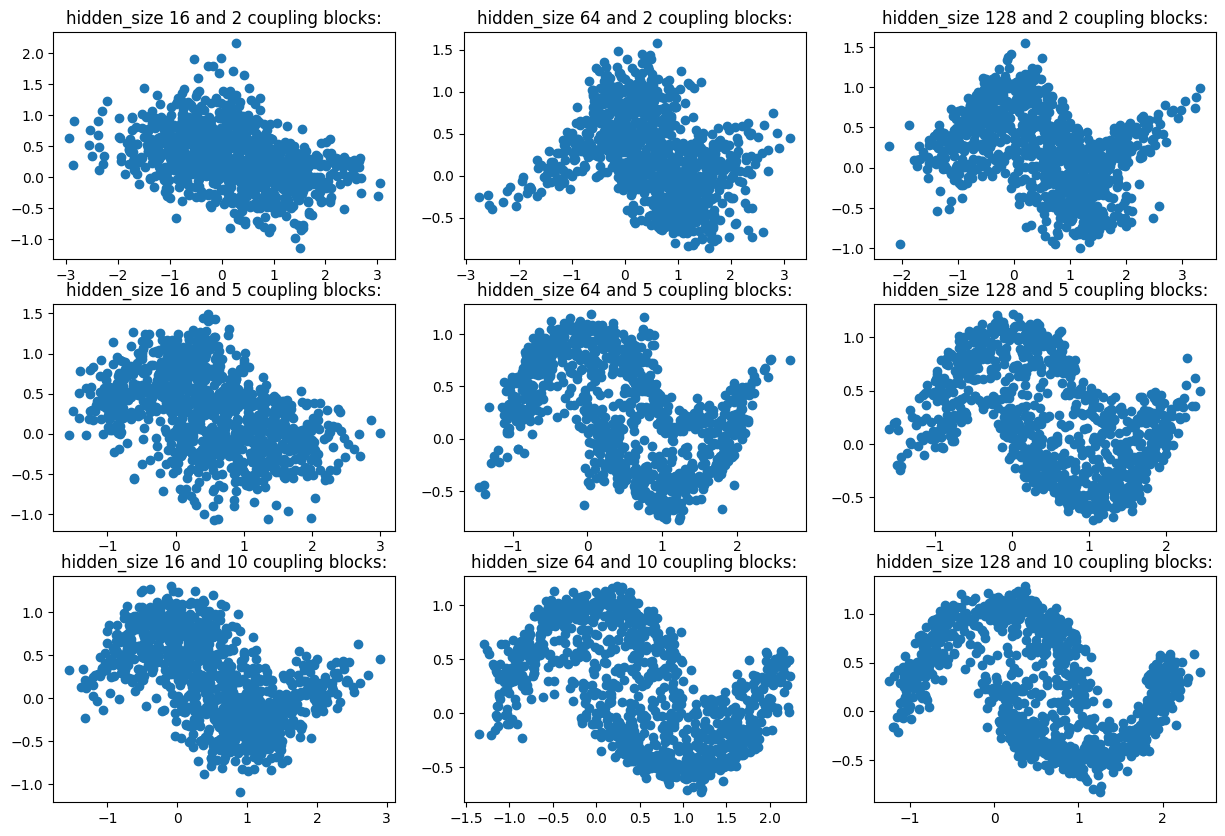

In [24]:
n_blocks = [2, 5, 10]
hidden_sizes = [16, 64, 128]
fig, axs = plt.subplots(3,3,figsize=(15,10))
for n in range(3):
 for h in range(3):
  model = realNVP(2, hidden_sizes[h], n_blocks[n])
  print(f"Training of INN with hidden_size {hidden_sizes[h]} and {n_blocks[n]} coupling blocks started.")
  train_inn(model, epochs=100, lr=0.001)
  plot_samples(model, title=f"hidden_size {hidden_sizes[h]} and {n_blocks[n]} coupling blocks:", axs=axs[n, h])


Training of INN with hidden_size 16 and 2 coupling blocks started.
Epoch [333/1000], Loss: -0.0636
Epoch [666/1000], Loss: -0.1858
Epoch [999/1000], Loss: -0.2738
Training of INN with hidden_size 64 and 2 coupling blocks started.
Epoch [333/1000], Loss: -0.5158
Epoch [666/1000], Loss: -0.6099
Epoch [999/1000], Loss: -0.6313
Training of INN with hidden_size 128 and 2 coupling blocks started.
Epoch [333/1000], Loss: -0.5483
Epoch [666/1000], Loss: -0.5839
Epoch [999/1000], Loss: -0.5997
Training of INN with hidden_size 16 and 5 coupling blocks started.
Epoch [333/1000], Loss: -0.7266
Epoch [666/1000], Loss: -0.8234
Epoch [999/1000], Loss: -0.8430
Training of INN with hidden_size 64 and 5 coupling blocks started.
Epoch [333/1000], Loss: -0.8395
Epoch [666/1000], Loss: -0.8789
Epoch [999/1000], Loss: -0.8922
Training of INN with hidden_size 128 and 5 coupling blocks started.
Epoch [333/1000], Loss: -0.8722
Epoch [666/1000], Loss: -0.9059
Epoch [999/1000], Loss: -0.9270
Training of INN with

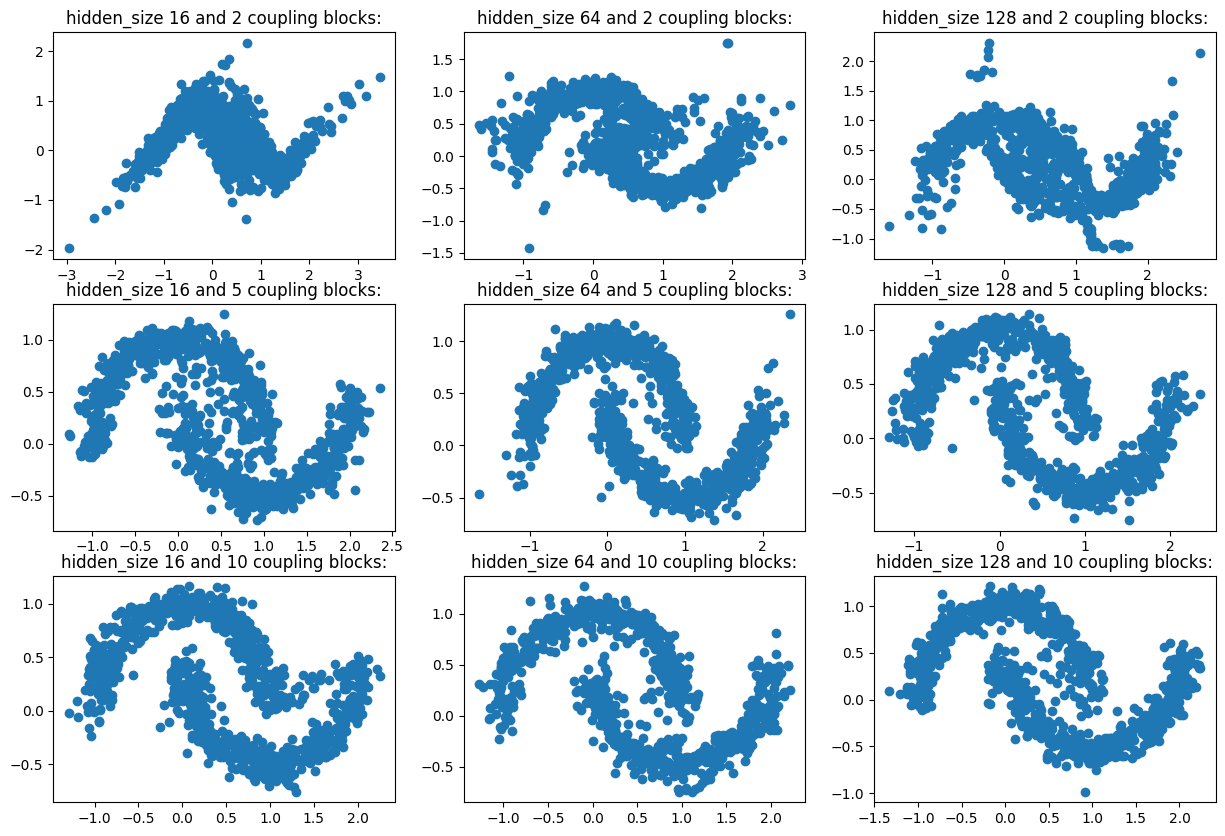

In [25]:
n_blocks = [2, 5, 10]
hidden_sizes = [16, 64, 128]
fig, axs = plt.subplots(3,3,figsize=(15,10))
for n in range(3):
 for h in range(3):
  model = realNVP(2, hidden_sizes[h], n_blocks[n])
  print(f"Training of INN with hidden_size {hidden_sizes[h]} and {n_blocks[n]} coupling blocks started.")
  train_inn(model, epochs=1000, lr=0.001)
  plot_samples(model, title=f"hidden_size {hidden_sizes[h]} and {n_blocks[n]} coupling blocks:", axs=axs[n, h])

Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.05.
Epoch [333/1000], Loss: -0.4731
Epoch [666/1000], Loss: -0.5004
Epoch [999/1000], Loss: -0.5370
Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.01.
Epoch [333/1000], Loss: -0.5481
Epoch [666/1000], Loss: -0.5598
Epoch [999/1000], Loss: -0.5606
Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.0005.
Epoch [333/1000], Loss: -0.4989
Epoch [666/1000], Loss: -0.6014
Epoch [999/1000], Loss: -0.6166
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.05.
Epoch [333/1000], Loss: -0.7438
Epoch [666/1000], Loss: -0.7825
Epoch [999/1000], Loss: -0.8115
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.01.
Epoch [333/1000], Loss: -0.8408
Epoch [666/1000], Loss: -0.8756
Epoch [999/1000], Loss: -0.8900
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.0005.
Epoch [333/1000], Loss: -0.7158
E

'learning_rates = [0.05, 0.01, 0.0005]\nhidden_sizes = [64, 16, 64]\nn_blocks = [2, 10, 10]\nfig, axs = plt.subplots(3,3,figsize=(15,10))\nfor m in range(3):\n for lr in range(3):\n model = realNVP(2, hidden_sizes[m], n_blocks[m])\n print(f"Training of INN with hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks st\narted with lr={learning_rates[lr]}.")\n train_inn(model, epochs=1000, lr=learning_rates[lr])\n plot_samples(model, title=f"hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks (lr\n={learning_rates[lr]}):", axs=axs[m, lr])\n'

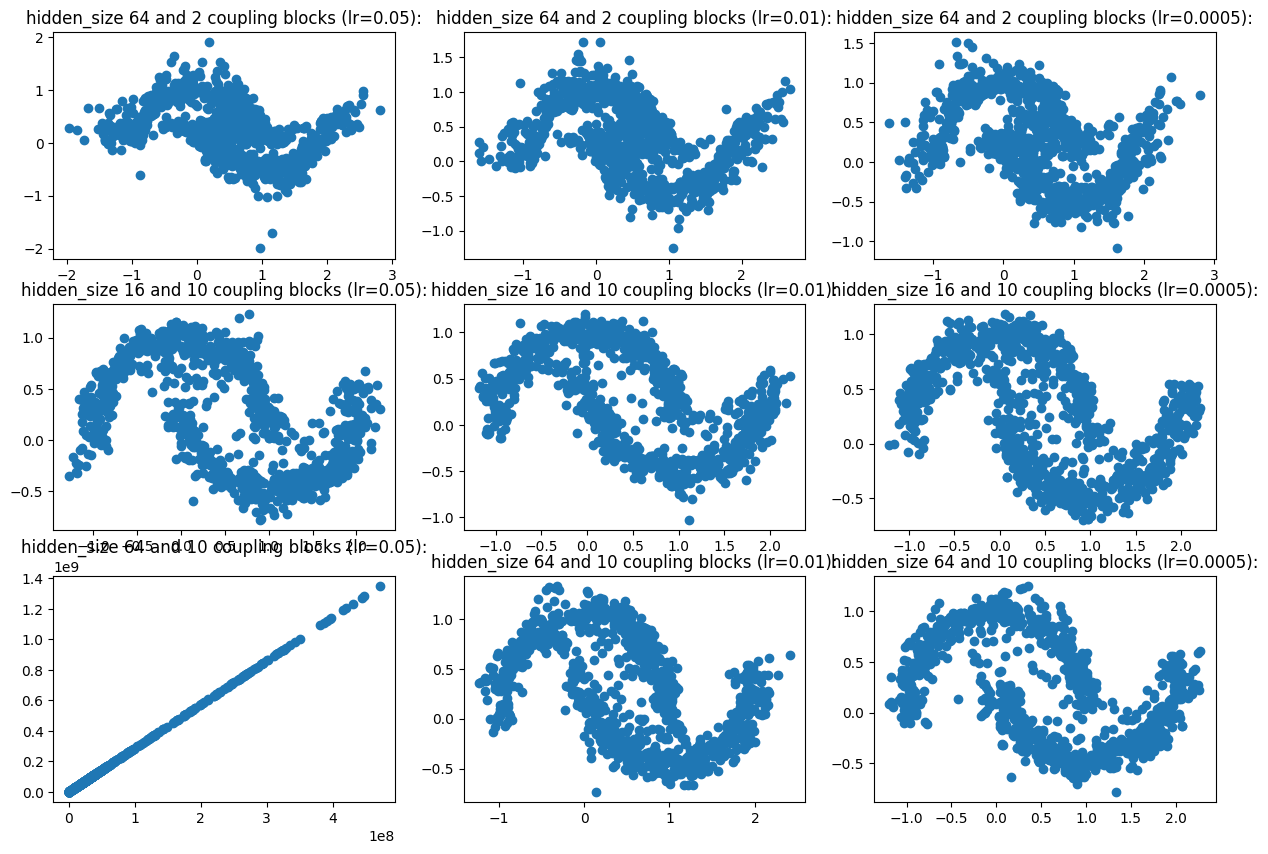

In [26]:
learning_rates = [0.05, 0.01, 0.0005]
hidden_sizes = [64, 16, 64] 
n_blocks = [2, 10, 10]
fig, axs = plt.subplots(3,3,figsize=(15,10))   
for m in range(3):
 for lr in range(3):
  model = realNVP(2, hidden_sizes[m], n_blocks[m])
  print(f"Training of INN with hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks started with lr={learning_rates[lr]}.")
  train_inn(model, epochs=1000, lr=learning_rates[lr])
  plot_samples(model, title=f"hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks (lr={learning_rates[lr]}):", axs=axs[m, lr])  
  

"""learning_rates = [0.05, 0.01, 0.0005]
hidden_sizes = [64, 16, 64]
n_blocks = [2, 10, 10]
fig, axs = plt.subplots(3,3,figsize=(15,10))
for m in range(3):
 for lr in range(3):
 model = realNVP(2, hidden_sizes[m], n_blocks[m])
 print(f"Training of INN with hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks st
arted with lr={learning_rates[lr]}.")
 train_inn(model, epochs=1000, lr=learning_rates[lr])
 plot_samples(model, title=f"hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks (lr
={learning_rates[lr]}):", axs=axs[m, lr])
"""

In [27]:
def mmd_inverse_multi_quadratic(x, y, bandwidths=None):
 batch_size = x.size()[0]
 # compute the kernel matrices for each combination of x, y
 # (cleverly using broadcasting to do this efficiently)
 xx, yy, xy = torch.mm(x,x.t()), torch.mm(y,y.t()), torch.mm(x,y.t())
 rx = (xx.diag().unsqueeze(0).expand_as(xx))
 ry = (yy.diag().unsqueeze(0).expand_as(yy))
 # compute the sum of kernels at different bandwidths
 K, L, P = 0, 0, 0
 if bandwidths is None:
  bandwidths = [0.4, 0.8, 1.6]
 for sigma in bandwidths:
  s = 1.0 / sigma**2
  K += 1.0 / (1.0 + s * (rx.t() + rx - 2.0*xx))
  L += 1.0 / (1.0 + s * (ry.t() + ry - 2.0*yy))
  P += 1.0 / (1.0 + s * (rx.t() + ry - 2.0*xy))
 beta = 1./(batch_size*(batch_size-1)*len(bandwidths))
 gamma = 2./(batch_size**2 * len(bandwidths))
 return beta * (torch.sum(K)+torch.sum(L)) - gamma * torch.sum(P)



Training of INN with 1 coupling block(s) started.
Epoch [333/1000], Loss: -0.0058
Epoch [666/1000], Loss: -0.0161
Epoch [999/1000], Loss: -0.0182
Training of INN with 2 coupling block(s) started.
Epoch [333/1000], Loss: -0.5186
Epoch [666/1000], Loss: -0.5794
Epoch [999/1000], Loss: -0.5898
Training of INN with 5 coupling block(s) started.
Epoch [333/1000], Loss: -0.7830
Epoch [666/1000], Loss: -0.8539
Epoch [999/1000], Loss: -0.8750
Training of INN with 7 coupling block(s) started.
Epoch [333/1000], Loss: -0.8896
Epoch [666/1000], Loss: -0.9373
Epoch [999/1000], Loss: -0.9636
Training of INN with 10 coupling block(s) started.
Epoch [333/1000], Loss: -0.8592
Epoch [666/1000], Loss: -0.8950
Epoch [999/1000], Loss: -0.9361
Training of INN with 15 coupling block(s) started.
Epoch [333/1000], Loss: -0.8994
Epoch [666/1000], Loss: -0.9372
Epoch [999/1000], Loss: -0.9384


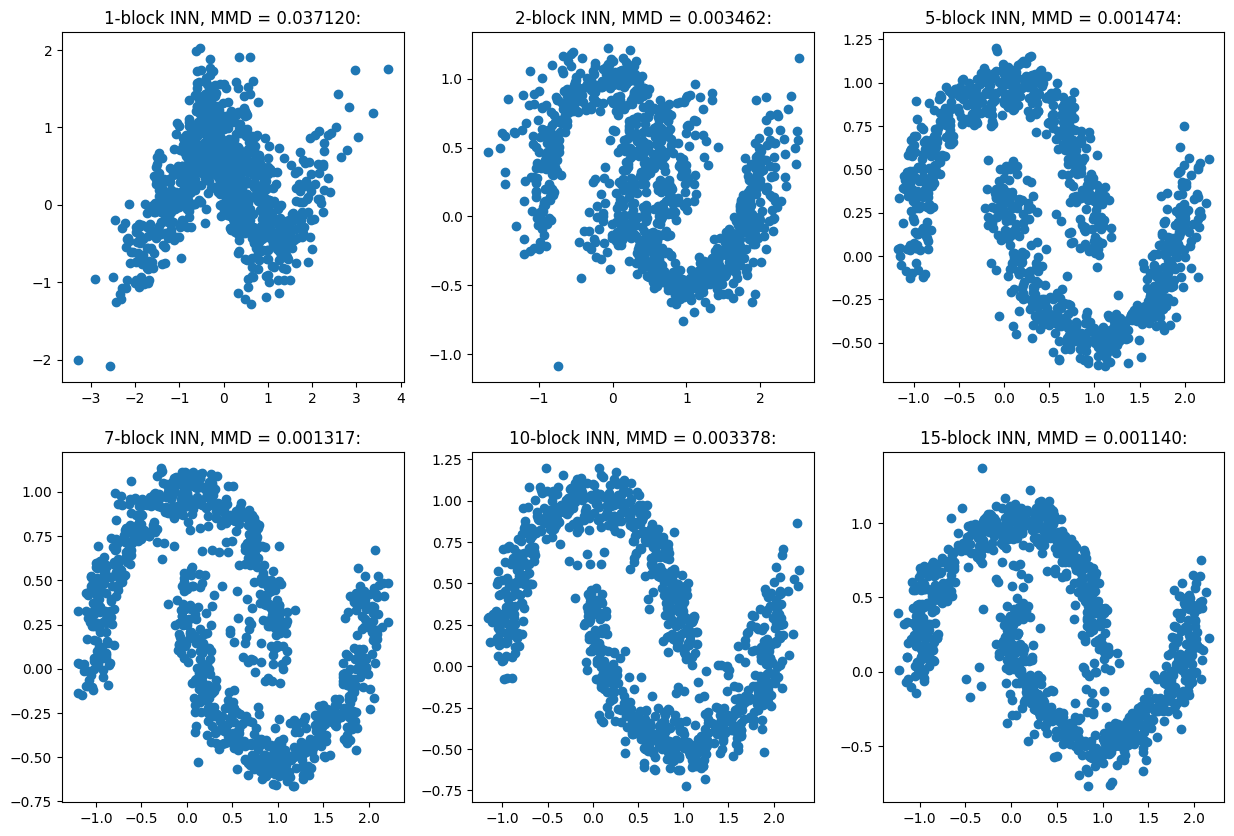

In [28]:
x, _= make_moons(n_samples=1000, shuffle=True, noise=0.1, random_state=42)
x = torch.Tensor(x)
# use n_blocks as variable parameter for model quality
n_blocks = (1, 2, 5, 7, 10, 15)
fig, axs = plt.subplots(2,3,figsize=(15,10))
axs = axs.flatten()
for n in range(6):
 model = realNVP(2, 64, n_blocks[n])
 print(f"Training of INN with {n_blocks[n]} coupling block(s) started.")
 train_inn(model)

 samples = model.sample(1000)
 mmd = mmd_inverse_multi_quadratic(samples, x)

 plot_samples(model, title=f"{n_blocks[n]}-block INN, MMD = {mmd:.6f}:", axs=axs[n])

In [30]:
def make_gmm_samples(n_samples):
    a = 0.5*math.sqrt(3)
    centers = torch.Tensor([[-1, 0],
    [-0.5, -a],
    [ 0.5, -a],
    [1, 0],
    [0.5, a],
    [-0.5, a]])
    stddev = torch.Tensor([0.1, 0.1])
    samples = []
    indices = []
    for i in range(n_samples):
        j = random.randint(0,5)
        indices.append(j)
        samples.append(torch.normal(centers[j], stddev))
    return torch.stack(samples), torch.Tensor(indices)

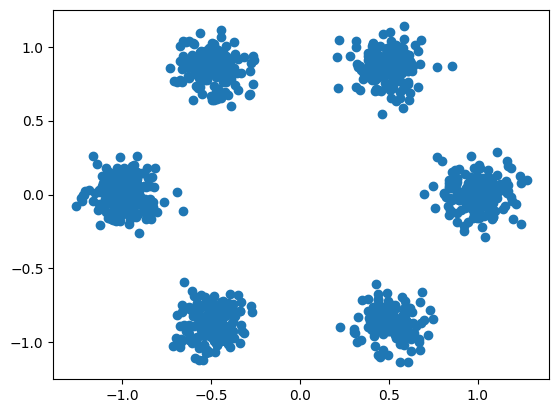

In [31]:
samples, _= make_gmm_samples(1000)
plt.scatter(samples[:,0], samples[:,1])


In [32]:
def train_gmm_inn(model, batchsize=1000, epochs=1000, lr=0.001):
    optimizer = torch.optim.Adam(params=model.parameters(), lr=lr)
    for epoch in range(epochs):
        optimizer.zero_grad()
        x_data, _ = make_gmm_samples(batchsize)
 
        z, ljd = model(x_data)
        loss = torch.sum(0.5*torch.sum(z**2, -1)-ljd) / batchsize
        loss.backward()
        optimizer.step()
        if (epoch+1) % (epochs//3) == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [333/1000], Loss: -1.5513
Epoch [666/1000], Loss: -1.6707
Epoch [999/1000], Loss: -1.6802
MMD of generated data with training data: 0.001965


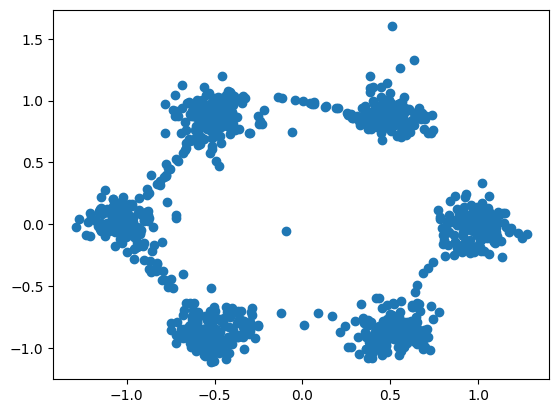

In [33]:
gmm_model = realNVP(2, 64, 10)
train_gmm_inn(gmm_model)
samples = gmm_model.sample(1000)
plt.scatter(samples.detach().numpy()[:,0], samples.detach().numpy()[:,1])
true_data, _ = make_gmm_samples(1000)
print(f"MMD of generated data with training data: {mmd_inverse_multi_quadratic(samples, true_data):.6f}")

Epoch [333/1000], Loss: -1.5829
Epoch [666/1000], Loss: -1.5973
Epoch [999/1000], Loss: -1.6259
Epoch [1666/5000], Loss: -1.6908
Epoch [3332/5000], Loss: -1.8111
Epoch [4998/5000], Loss: -1.7762


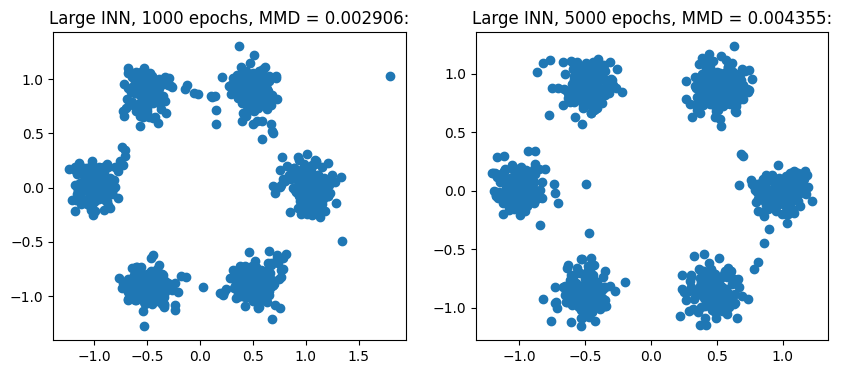

In [35]:
n_epochs = [1000, 5000]
true_data, _ = make_gmm_samples(1000)
figs, axs = plt.subplots(1,2, figsize=(10, 4))
for e in range(2):
    larger_gmm_model=realNVP(2, 128, 15)
    train_gmm_inn(larger_gmm_model, epochs=n_epochs[e])
    samples = larger_gmm_model.sample(1000)
 
    axs[e].scatter(samples[:,0].detach().numpy(), samples[:,1].detach().numpy())
    axs[e].set_title(f"Large INN, {n_epochs[e]} epochs, MMD = {mmd_inverse_multi_quadratic(samples, true_data):.6f}:")


In [37]:
class conditional_coupling_block(nn.Module):
    def __init__(self, input_size, hidden_size, condition_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.condition_size = condition_size
        self.split1 = math.floor(self.input_size/2)
        self.split2 = self.input_size - self.split1
        self.subnet = subnet_constructor(self.split1 + self.condition_size, self.hidden_size, 2*self.split2)
    
    def forward(self, x, cond, rev=False):
        x1, x2 = x[..., :self.split1], x[..., self.split1:]
        params = self.subnet(torch.cat([x1, cond], -1))
        s, t = params[...,:self.split2], params[...,self.split2:]
        s = torch.tanh(s)
        ljd = torch.sum(s, -1)
        
        if not rev:
            s = torch.exp(s)
            x2 = s*x2 + t
            return torch.cat([x1,x2], -1), ljd
        if rev:
            s = torch.exp(-s)
            x2 = s * (x2-t)
            return torch.cat([x1,x2], -1)

class conditional_realNVP(nn.Module):
    def __init__(self, input_size, hidden_size, n_blocks, condition_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.n_blocks = n_blocks
        self.condition_size = condition_size
        
        self.coupling_blocks = nn.ModuleList([conditional_coupling_block(input_size, hidden_size, self.condition_size) for _ in range(n_blocks)])
        self.orthogonal_matrices = [orthogoanl_matrix(input_size) for _ in range(n_blocks-1)]
    
    def forward(self, x, cond, rev=False):
        if rev: 
            return self._inverse(x, cond)
        return self._forward(x, cond)
    
    def _forward(self, x, cond):
        cond = nn.functional.one_hot(cond.to(torch.int64), num_classes=self.condition_size)
        ljd = torch.zeros((x.shape[0]))
        for l in range(self.n_blocks-1):
            x, partial_ljd = self.coupling_blocks[l](x, cond)
            ljd += partial_ljd
            x = torch.matmul(x, self.orthogonal_matrices[l])
        x, partial_ljd = self.coupling_blocks[-1](x, cond)
        ljd += partial_ljd
        return x, ljd
    
    def _inverse(self, x, cond):
        cond = nn.functional.one_hot(cond.to(torch.int64), num_classes=self.condition_size)
        for l in range(self.n_blocks-1, 0, -1):
            x = self.coupling_blocks[l](x, cond, rev=True)
            x = torch.matmul(x, self.orthogonal_matrices[l-1].T)
        x = self.coupling_blocks[0](x, cond, rev=True)
        return x
    
    def sample(self, num_samples, cond=None):
        samples = []
        if cond is None:
            for c in range(self.condition_size):
                z = torch.normal(mean=torch.zeros((num_samples, self.input_size)), std=torch.ones((num_samples, self.input_size)))
                samples.append(self._inverse(z, cond=c*torch.ones(num_samples)))
        else:
            z = torch.normal(mean=torch.zeros((num_samples, self.input_size)), std=torch.ones((num_samples, self.input_size)))
            samples.append(self._inverse(z, cond=cond*torch.ones(num_samples)))
        return torch.cat(samples, 0)

Epoch [33/100], Loss: -0.9808
Epoch [66/100], Loss: -1.4792
Epoch [99/100], Loss: -1.5563


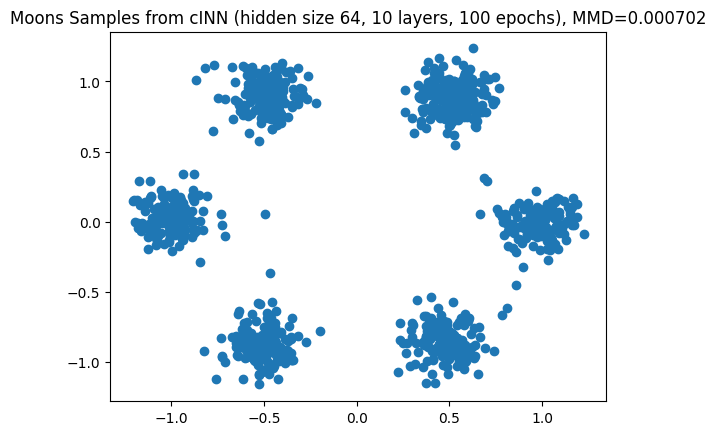

In [41]:
def train_cinn_moons(model, batchsize=1000, epochs=1000, lr=0.001):
 optimizer = torch.optim.Adam(params=model.parameters(), lr=lr)
 for epoch in range(epochs):
    optimizer.zero_grad()
    x_data, y_data = make_moons(n_samples=batchsize, shuffle=True, noise=0.1, random_state=42)
    x_data, y_data = torch.Tensor(x_data), torch.Tensor(y_data)
    z, ljd = model(x_data, y_data)
    loss = torch.sum(0.5*torch.sum(z**2, -1)-ljd) / batchsize
    loss.backward()
    optimizer.step()
    if (epoch+1) % (epochs//3) == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")
cINN_moons = conditional_realNVP(2, 64, 10, 2)
train_cinn_moons(cINN_moons, epochs=100)
moons_samples = cINN_moons.sample(1000)
true_moons_data, _ = make_moons(n_samples=2000, shuffle=True, noise=0.1, random_state=42)
true_moons_data = torch.Tensor(true_moons_data)
plt.scatter(samples[:,0].detach().numpy(), samples[:,1].detach().numpy())
mmd_score = mmd_inverse_multi_quadratic(moons_samples, true_moons_data)
plt.title(f"Moons Samples from cINN (hidden size 64, 10 layers, 100 epochs), MMD={mmd_score:.6f}")
plt.show()


In [47]:
def cluster_mode_labels(cond):
 is_cluster_1 = torch.logical_or(cond == 4, cond == 5)
 return is_cluster_1.to(torch.int)

def train_cinn_gmm(model, batchsize=1000, epochs=1000, lr=0.001, binary=False):
optimizer = torch.optim.Adam(params=model.parameters(), lr=lr)
 for epoch in range(epochs):
    optimizer.zero_grad()
    x_data, y_data = make_gmm_samples(1000)
    if binary: y_data = cluster_mode_labels(y_data)
     z, ljd = model(x_data, y_data)
    loss = torch.sum(0.5*torch.sum(z**2, -1)-ljd) / batchsize
    loss.backward()
    optimizer.step()
    if (epoch+1) % (epochs//3) == 0:
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

IndentationError: expected an indented block after function definition on line 5 (2197228446.py, line 6)